In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import platform

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

funnel = pd.read_csv("../Soyun_EDA/funnel_instance.csv")
full   = pd.read_csv("../Soyun_EDA/final_eda.csv")

In [2]:
# _x suffix 제거 / _y 컬럼 제거
funnel.columns = funnel.columns.str.replace(r"_x$", "", regex=True)
funnel = funnel.drop(columns=[c for c in funnel.columns if c.endswith("_y")], errors="ignore")

# 고객 속성 병합
cust_attr = (
    full[["customer_id", "gender", "age_group", "income_group", "income"]]
    .drop_duplicates("customer_id")
)
funnel = funnel.merge(cust_attr, on="customer_id", how="left", suffixes=("", "_dup"))
funnel = funnel.drop(columns=[c for c in funnel.columns if c.endswith("_dup")], errors="ignore")

In [3]:
# ============================================================
# 1. 고객별 완료율 + 평균 거래금액 계산
# ============================================================

# 완료율: bogo/discount 인스턴스 중 완료 비율
offer_funnel = funnel[funnel["offer_type"].isin(["bogo", "discount"])].copy()

cr_per_cust = (
    offer_funnel.groupby("customer_id")["was_completed"]
    .mean()
    .rename("completion_rate")
)

# 평균 거래금액 (상위 1% 제거)
tx = full[full["event"] == "transaction"].copy()
amount_upper = tx["amount"].quantile(0.99)
tx = tx[tx["amount"] <= amount_upper]

amt_per_cust = (
    tx.groupby("customer_id")["amount"]
    .mean()
    .rename("avg_amount")
)

cust_grade = pd.concat([cr_per_cust, amt_per_cust], axis=1).dropna()
print(f"분석 대상 고객: {len(cust_grade):,}명")
print(cust_grade.describe().round(2))

분석 대상 고객: 16,505명
       completion_rate  avg_amount
count         16505.00    16505.00
mean              0.56       11.97
std               0.39        8.94
min               0.00        0.05
25%               0.20        3.11
50%               0.60       11.43
75%               1.00       19.79
max               1.00       38.58


In [ ]:
# ============================================================
# 2. 등급 분류 (중앙값 기준)
# ============================================================

# 오퍼 수신 횟수 분포 확인 (1회 고객 비율이 높으면 완료율이 0/1로 몰림)
recv_count = offer_funnel.groupby("customer_id").size()
one_time = (recv_count == 1).sum()
print(f"오퍼 수신 1회 고객: {one_time:,}명 ({one_time/len(recv_count)*100:.1f}%) → 완료율 분포 안정성 확인용")

cr_med  = cust_grade["completion_rate"].median()
amt_med = cust_grade["avg_amount"].median()

print(f"\n완료율 중앙값: {cr_med:.2f}")
print(f"거래금액 중앙값: ${amt_med:.2f}")

# 중앙값 경계 근처 고객 비율 (±5% 구간)
boundary_cr  = ((cust_grade["completion_rate"] - cr_med).abs() / cr_med <= 0.05).sum()
boundary_amt = ((cust_grade["avg_amount"]      - amt_med).abs() / amt_med <= 0.05).sum()
print(f"\n경계 근처 고객 (완료율 ±5%): {boundary_cr:,}명 ({boundary_cr/len(cust_grade)*100:.1f}%)")
print(f"경계 근처 고객 (금액 ±5%):   {boundary_amt:,}명 ({boundary_amt/len(cust_grade)*100:.1f}%)")
print("→ 비율이 높으면 중앙값 분할에 민감한 구간이 많음을 의미")

def assign_grade(row):
    high_cr  = row["completion_rate"] >= cr_med
    high_amt = row["avg_amount"]      >= amt_med
    if   high_cr and     high_amt: return "VIP"
    elif not high_cr and high_amt: return "자발적 구매형"
    elif high_cr and not high_amt: return "반응형"
    else:                          return "저관여"

cust_grade["grade"] = cust_grade.apply(assign_grade, axis=1)

print("\n등급 분포:")
print(cust_grade["grade"].value_counts())

오퍼 수신 1회 고객: 642명 (3.8%) → 완료율 분포 안정성 확인용

완료율 중앙값: 0.60
거래금액 중앙값: $11.43

경계 근처 고객 (완료율 ±5%): 373명 (2.3%)
경계 근처 고객 (금액 ±5%):   408명 (2.5%)
→ 비율이 높으면 중앙값 분할에 민감한 구간이 많음을 의미

등급 분포:
grade
VIP        6655
저관여        6370
반응형        1882
자발적 구매형    1598
Name: count, dtype: int64


In [5]:
# ============================================================
# 3. 등급 × 세그먼트 교차 분석
# ============================================================

grade_attr = cust_grade.reset_index().merge(
    cust_attr[["customer_id", "gender", "income_group", "age_group"]],
    on="customer_id", how="left"
)

grade_order = ["VIP", "자발적 구매형", "반응형", "저관여"]
inc_order   = ["5만 미만", "5-7.5만", "7.5-10만", "10만 이상"]
age_order   = ["20대 미만", "20대", "30대", "40대", "50대", "60대 이상"]

print("\n[ 소득 구간별 등급 비율 (%) ]")
inc_grade = (
    grade_attr[grade_attr["income_group"].isin(inc_order)]
    .groupby("income_group")["grade"]
    .value_counts(normalize=True).unstack(fill_value=0) * 100
).reindex(inc_order)[grade_order]
print(inc_grade.round(1))

print("\n[ 성별 등급 비율 (%) ]")
gen_grade = (
    grade_attr[grade_attr["gender"].isin(["M","F"])]
    .groupby("gender")["grade"]
    .value_counts(normalize=True).unstack(fill_value=0) * 100
)[grade_order]
print(gen_grade.round(1))

print("\n[ 연령대별 등급 비율 (%) ]")
age_grade = (
    grade_attr[grade_attr["age_group"].isin(age_order)]
    .groupby("age_group")["grade"]
    .value_counts(normalize=True).unstack(fill_value=0) * 100
).reindex(age_order)[grade_order]
print(age_grade.round(1))


[ 소득 구간별 등급 비율 (%) ]
grade          VIP  자발적 구매형   반응형   저관여
income_group                           
5만 미만          6.6      0.7  31.3  61.4
5-7.5만        47.6     10.0   9.4  33.1
7.5-10만       76.6     21.9   0.2   1.2
10만 이상        80.3     19.7   0.0   0.0

[ 성별 등급 비율 (%) ]
grade    VIP  자발적 구매형   반응형   저관여
gender                           
F       60.0     14.0  10.4  15.6
M       35.9      8.9  13.5  41.6

[ 연령대별 등급 비율 (%) ]
grade       VIP  자발적 구매형   반응형   저관여
age_group                           
20대 미만     20.1      2.0  16.7  61.3
20대        18.7      1.5  23.2  56.6
30대        28.3      3.1  21.3  47.3
40대        44.0     11.7  11.1  33.2
50대        55.3     13.7   8.6  22.3
60대 이상     53.6     13.9   9.7  22.8


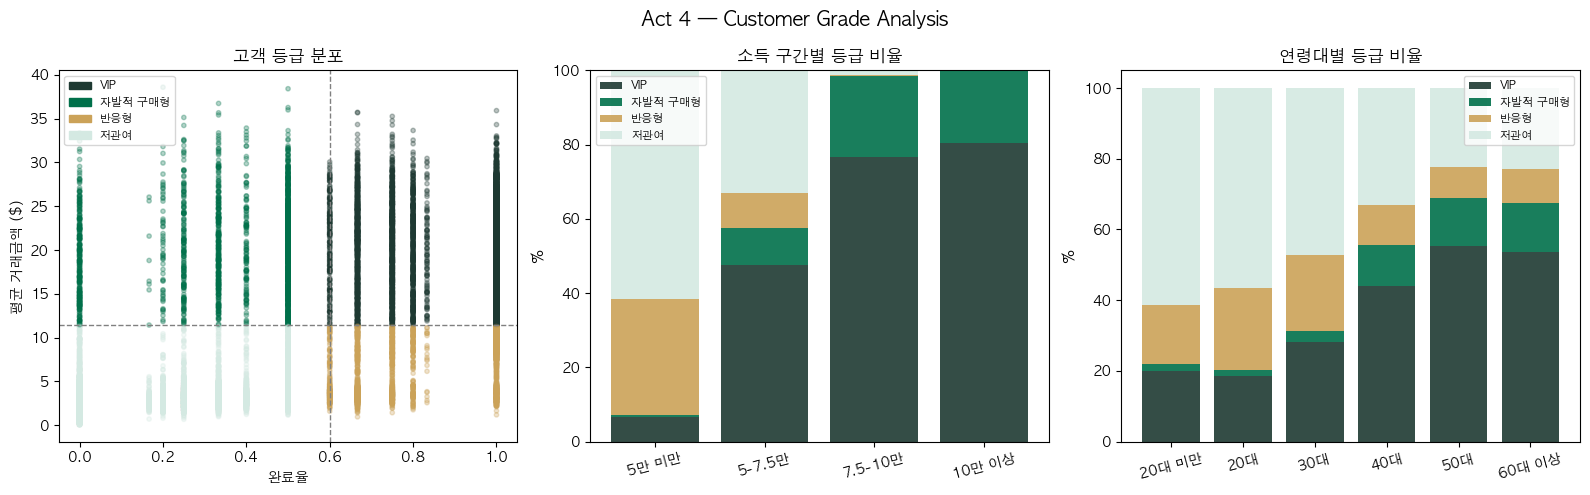

In [6]:
# ============================================================
# 4. 시각화
# ============================================================

green = "#00704A"; gold = "#CBA258"; dark = "#1E3932"; light = "#D4E9E2"
grade_colors = {"VIP": dark, "자발적 구매형": green, "반응형": gold, "저관여": light}
grade_order  = ["VIP", "자발적 구매형", "반응형", "저관여"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Act 4 — Customer Grade Analysis", fontsize=14, fontweight="bold")

# 차트 1: 산점도 (완료율 × 거래금액)
ax1 = axes[0]
colors = cust_grade["grade"].map(grade_colors)
ax1.scatter(cust_grade["completion_rate"], cust_grade["avg_amount"],
            c=colors, alpha=0.3, s=10)
ax1.axvline(cr_med,  color="gray", linestyle="--", linewidth=1)
ax1.axhline(amt_med, color="gray", linestyle="--", linewidth=1)
ax1.set_xlabel("완료율")
ax1.set_ylabel("평균 거래금액 ($)")
ax1.set_title("고객 등급 분포", fontweight="bold")
patches = [mpatches.Patch(color=v, label=k) for k, v in grade_colors.items()]
ax1.legend(handles=patches, fontsize=8)

# 차트 2: 소득 구간별 등급 누적 막대
ax2 = axes[1]
bottom = np.zeros(len(inc_order))
for grade in grade_order:
    vals = inc_grade[grade].values
    ax2.bar(inc_order, vals, bottom=bottom, label=grade, color=grade_colors[grade], alpha=0.9)
    bottom += vals
ax2.set_title("소득 구간별 등급 비율", fontweight="bold")
ax2.set_ylabel("%")
ax2.set_xticks(range(len(inc_order)))
ax2.set_xticklabels(inc_order, rotation=15)
ax2.legend(fontsize=8)

# 차트 3: 연령대별 등급 누적 막대
ax3 = axes[2]
bottom = np.zeros(len(age_order))
for grade in grade_order:
    vals = age_grade[grade].values
    ax3.bar(age_order, vals, bottom=bottom, label=grade, color=grade_colors[grade], alpha=0.9)
    bottom += vals
ax3.set_title("연령대별 등급 비율", fontweight="bold")
ax3.set_ylabel("%")
ax3.set_xticks(range(len(age_order)))
ax3.set_xticklabels(age_order, rotation=15)
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()